In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Activation, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split


2026-04-16 20:09:44.365445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776370184.596939      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776370184.669302      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776370185.251409      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776370185.251463      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776370185.251467      22 computation_placer.cc:177] computation placer alr

In [2]:
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("../input"))

import zipfile

with zipfile.ZipFile("/kaggle/input/dogs-vs-cats/train.zip","r") as z:
    z.extractall(".")
    
with zipfile.ZipFile("/kaggle/input/dogs-vs-cats/test1.zip","r") as z:
    z.extractall(".")

['dogs-vs-cats']


In [3]:
# Liste les GPUs visibles par TensorFlow
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU détecté : {gpus}")
    # Affiche le nom spécifique du GPU
    print(f"Détails : {tf.test.gpu_device_name()}")
else:
    print("❌ Aucun GPU détecté. Vérifie les paramètres de ta session Kaggle (Settings > Accelerator).")

✅ GPU détecté : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Détails : /device:GPU:0


I0000 00:00:1776370211.021866      22 gpu_device.cc:2019] Created device /device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


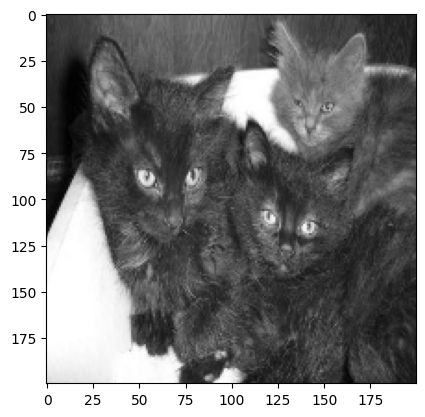

In [4]:
main_dir = "/kaggle/working/"
train_dir = "train"
path = os.path.join(main_dir,train_dir)

for p in os.listdir(path):
    category = p.split(".")[0]
    img_array = cv2.imread(os.path.join(path,p),cv2.IMREAD_GRAYSCALE)
    new_img_array = cv2.resize(img_array, dsize=(200, 200))
    plt.imshow(new_img_array,cmap='gray')
    break

In [5]:
X = []
y = []
convert = lambda category : int(category == 'dog')
def create_test_data(path):
    for p in os.listdir(path):
        category = p.split(".")[0]
        category = convert(category)
        img_array = cv2.imread(os.path.join(path,p),cv2.IMREAD_GRAYSCALE)
        new_img_array = cv2.resize(img_array, dsize=(200, 200))
        X.append(new_img_array)
        y.append(category)
    

In [6]:
create_test_data(path)
X = np.array(X).reshape(-1, 200,200,1)
y = np.array(y)

In [7]:
images_label_0 = X[y == 0]
images_label_1 = X[y == 1]


mean_val_0 = np.mean(images_label_0)
mean_val_1 = np.mean(images_label_1)

median_val_0 = np.median(images_label_0)
median_val_1 = np.median(images_label_1)

std_0 = np.std(images_label_0)
std_1 = np.std(images_label_1)

print(f"Label Chat\nIntensité moyenne (: {mean_val_0:.2f})\nIntensité médiane (: {median_val_0:.2f})\nStandard Deviation (: {std_0:.2f})")
print(" ")
print(f"Label Chien\nIntensité moyenne (: {mean_val_1:.2f})\nIntensité médiane (: {median_val_1:.2f})\nStandard Deviation : {std_1:.2f})") 

Label Chat
Intensité moyenne (: 116.08)
Intensité médiane (: 113.00)
Standard Deviation (: 65.74)
 
Label Chien
Intensité moyenne (: 118.66)
Intensité médiane (: 116.00)
Standard Deviation : 62.46)


In [8]:
X = X/255

In [9]:
print(X.shape)

(25000, 200, 200, 1)


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    np.array(X), np.array(y), 
    test_size=0.2, 
    random_state=42, 
    shuffle=True
)

In [11]:
model=keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomContrast(0.5),
    layers.Conv2D(64,(3,3), activation = 'relu', input_shape = X.shape[1:]),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Conv2D(64,(3,3), activation = 'relu'),
    layers.MaxPooling2D(pool_size = (2,2)),
    layers.Flatten(),
    layers.Dense(units=64, activation ='relu'),
    layers.Dropout(rate=0.3),
    layers.Dense(units=24, activation= 'relu'),
    #layers.Dropout(rate=0.3),
    #layers.Dense(units=6,activation= 'relu'),
    layers.Dense (units=1, activation= 'sigmoid')
                 
])


I0000 00:00:1776370251.238754      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(optimizer= Adam (learning_rate=0.0005, epsilon=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [13]:
early_stopping = EarlyStopping(
  	  min_delta=0.01, # minimium amount of change to count as an improvement
   	  patience=5, # how many epochs to wait before stopping
   	  restore_best_weights=True)


In [14]:
epochs = 25
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=32, 
                    validation_data=(X_val,y_val),
                    callbacks=early_stopping)

Epoch 1/25


I0000 00:00:1776370262.803406      66 service.cc:152] XLA service 0x7a17d800d280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776370262.803505      66 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776370263.516305      66 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/625 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.4724 - loss: 0.6926

I0000 00:00:1776370269.467243      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.5359 - loss: 0.6864 - val_accuracy: 0.6324 - val_loss: 0.6502
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6137 - loss: 0.6497 - val_accuracy: 0.6836 - val_loss: 0.6068
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6529 - loss: 0.6188 - val_accuracy: 0.7354 - val_loss: 0.5663
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7257 - loss: 0.5457 - val_accuracy: 0.7498 - val_loss: 0.5322
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7523 - loss: 0.5133 - val_accuracy: 0.7566 - val_loss: 0.4989
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7786 - loss: 0.4707 - val_accuracy: 0.7740 - val_loss: 0.4767
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.7975 - loss: 0.4357 - val_accuracy: 0.7834 - val_loss: 0.4494
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.8217 - loss: 0.3971 - val_accurac

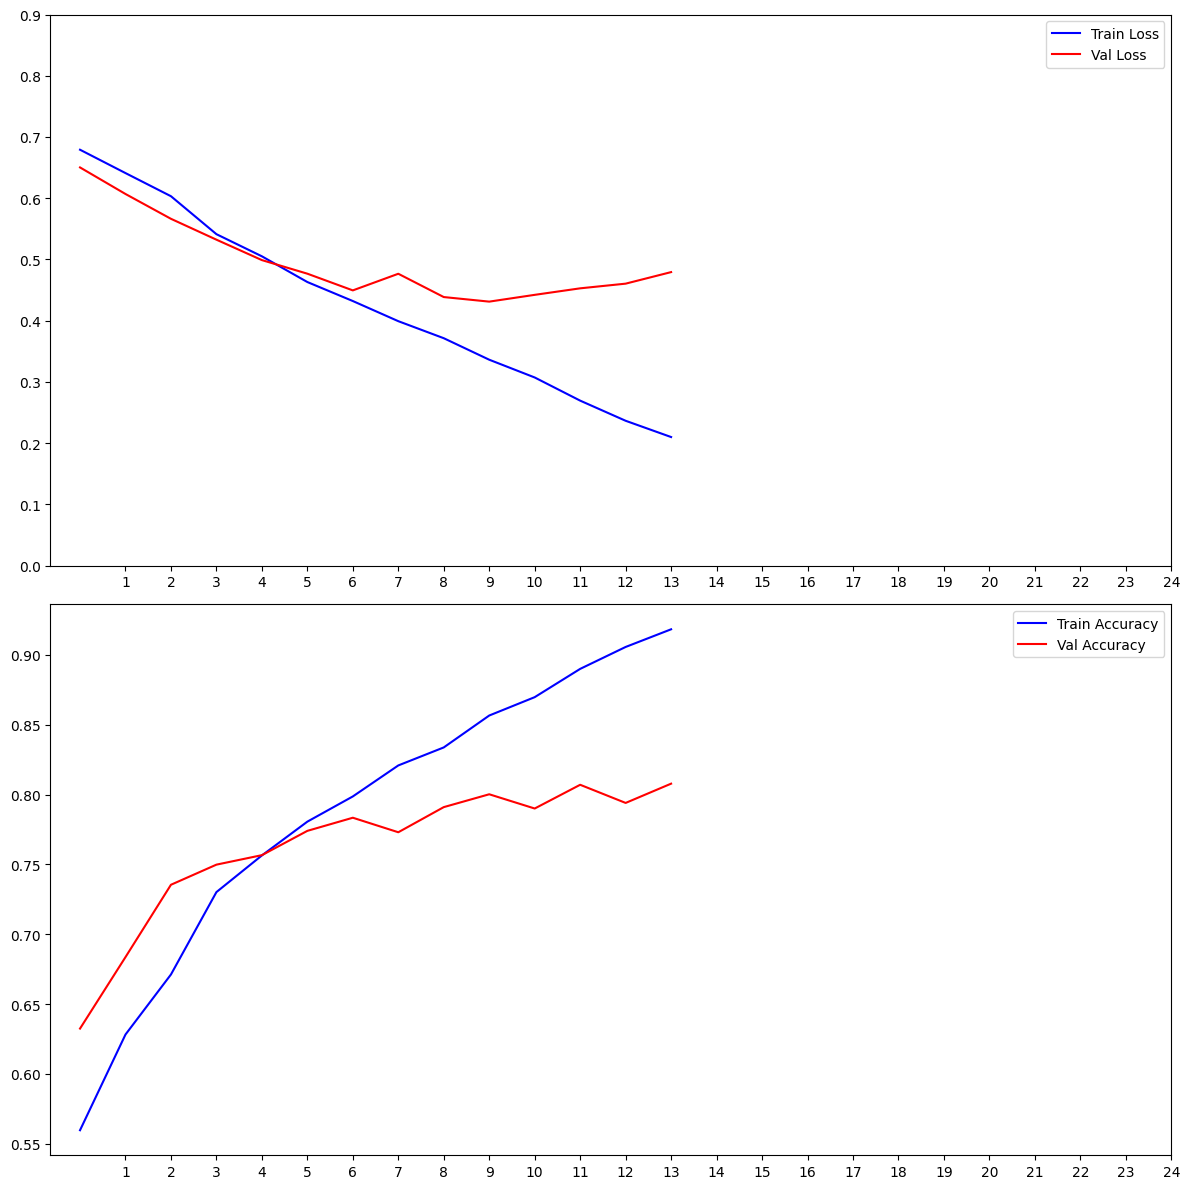

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(history.history['loss'], color='b', label="Training loss")
ax1.plot(history.history['val_loss'], color='r', label="Validation loss")
ax1.set_xticks(np.arange(1, epochs, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))
ax1.legend(['Train Loss','Val Loss'])

ax2.plot(history.history['accuracy'], color='b', label="Training")
ax2.plot(history.history['val_accuracy'], color='r',label="Validation")
ax2.set_xticks(np.arange(1, epochs, 1))
ax2.legend(['Train Accuracy', 'Val Accuracy'])


plt.tight_layout()
plt.show()

In [16]:
y_pred_probs = model.predict(X_val)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [17]:
y_pred = (y_pred_probs > 0.5).astype(int)
y_true = y_val

In [18]:
print(confusion_matrix(y_pred,y_true))
print(classification_report(y_pred,y_true))

[[2136  625]
 [ 420 1819]]
              precision    recall  f1-score   support

           0       0.84      0.77      0.80      2761
           1       0.74      0.81      0.78      2239

    accuracy                           0.79      5000
   macro avg       0.79      0.79      0.79      5000
weighted avg       0.79      0.79      0.79      5000



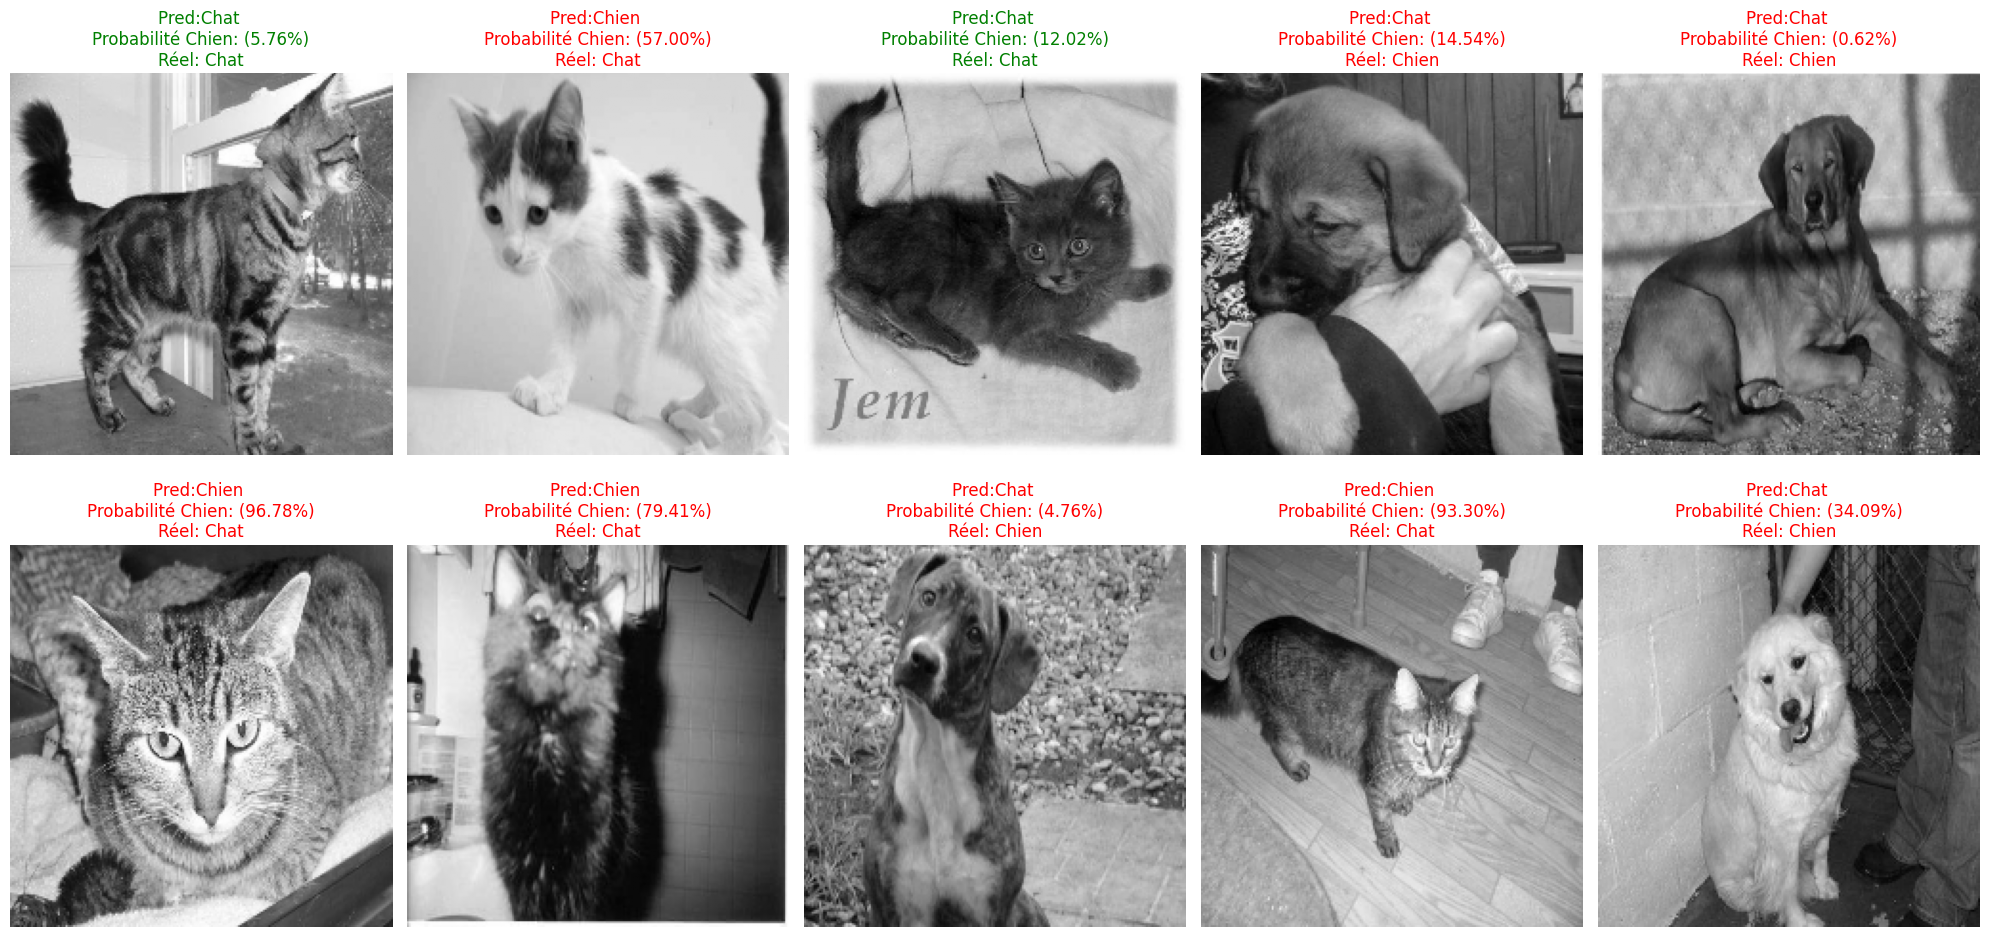

In [19]:
indices = np.random.choice(len(X_val), 10, replace=False)
sample_images = X_val[indices]
sample_labels = y_val[indices]

plt.figure(figsize=(20, 10))
class_names= {1:'Chien', 0: 'Chat'}

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    p_idx = 1 if y_pred_probs[i] > 0.5 else 0
    t_idx = int(sample_labels[i])  
        
    color = 'green' if p_idx == t_idx else 'red'
    plt.axis('off')
    plt.title(f"Pred:{class_names[p_idx]} \nProbabilité Chien: ({100*np.max(y_pred_probs[i]):.2f}%)\nRéel: {class_names[t_idx]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()